In [2]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import missingno as msno
import seaborn as sns
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## This notebook is for our introductory exploratory data analysis.

It contains distributions and descriptive stats, missingness analysis, visualizations of relationships between variables, and outlier detection.

In [3]:
# Same data pre-processing as the learnability and KPI analysis

# Load and integrate data
repo = Path.cwd().parent
data_dir = repo / "data" / "raw"

# Load raw CSV components
adv = pd.read_csv(data_dir / "2025_advanced.csv")
per = pd.read_csv(data_dir / "2025_per_game.csv")
tot = pd.read_csv(data_dir / "2025_totals.csv")
sal = pd.read_csv(data_dir / "salary_2025.csv")
teamadv = pd.read_csv(data_dir / "2025_advanced-team.csv")
stand = pd.read_csv(data_dir / "2025_wnba_standings.csv")


# Standardize column names into a code-friendly format
def clean_col(name):
    text = str(name).strip().lower()
    text = text.replace("2025 salary", "salary")
    text = text.replace("2025 signing", "signing")
    text = text.replace("%", "pct")
    text = re.sub(r"[^0-9a-z]+", "_", text)
    return text.strip("_")


# Apply column-name standardizations and strip whitespace from text features
def clean_df(df):
    df.columns = [clean_col(col) for col in df.columns]
    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = df[col].astype(str).str.strip().replace({"": np.nan, "—": np.nan, "nan": np.nan})
    return df


adv, per, tot = clean_df(adv), clean_df(per), clean_df(tot)
sal, teamadv, stand = clean_df(sal), clean_df(teamadv), clean_df(stand)

# Target preparation
sal["salary"] = pd.to_numeric(sal["salary"], errors="coerce")

# Map full team names to uniform abbreviations
teammap = {
    "Atlanta Dream": "ATL", "Chicago Sky": "CHI", "Connecticut Sun": "CON",
    "Dallas Wings": "DAL", "Golden State Valkyries": "GSV", "Indiana Fever": "IND",
    "Las Vegas Aces": "LVA", "Los Angeles Sparks": "LAS", "Minnesota Lynx": "MIN",
    "New York Liberty": "NYL", "Phoenix Mercury": "PHO", "Seattle Storm": "SEA",
    "Washington Mystics": "WAS"
}

teamadv["team"] = teamadv["team"].str.replace("*", "", regex=False).str.strip().map(teammap)
stand["team_name"] = stand["team_name"].str.replace("*", "", regex=False).str.strip().map(teammap)

# Merge structural sub-tables
teamdf = teamadv.merge(stand, left_on="team", right_on="team_name", how="left", suffixes=("_adv", "_stand"))
playerdf = per.merge(adv, on=["player", "team", "pos", "g", "mp"], how="outer")
playerdf = playerdf.merge(tot, on=["player", "team", "pos", "g", "mp", "gs"], how="outer")

# Correct name spelling/encoding anomalies to maximize merge coverage
name_fix = {
    "Anastasiia Kosu": "Anastasiia Olairi Kosu", "Janelle SalaÃ¼n": "Janelle Salaun",
    "LeÃ¯la Lacan": "Leila Lacan", "Luisa GeiselsÃ¶der": "Luisa Geiselsoder",
    "Mamignan TourÃ©": "Mamignan Touré", "MariÃ¨me Badiane": "Marième Badiane",
    "Te-Hina PaoPao": "Te-Hina Paopao", "Sika KonÃ©": "Sika Kone"
}
playerdf["player"] = playerdf["player"].replace(name_fix)

# Construct final modeling table
final_df = sal.merge(playerdf, on="player", how="inner", suffixes=("_sal", ""))
final_df = final_df.merge(teamdf, on="team", how="left")

## Distributions and Descriptive Stats
**Objective:** Understand the baseline mathematical spread of our target variable (`salary`) and our primary predictive features (like `ws` for Win Shares and `age`). 

By analyzing these univariate distributions, we can identify extreme skews, establish what a "league-average" player looks like, and visually diagnose the high volume of minimum-salary contracts that previously impacted our metrics. We will also look at cumulative distributions to understand compensation percentiles.

Baseline Descriptive Statistics


,salary,ws,age
count,224.00,224.00,170.00
mean,82837.83,1.30,27.85
std,68624.75,1.89,1.46
min,0.00,-1.20,24.80
25%,17220.75,0.00,27.10
50%,72455.00,0.65,28.10
75%,111519.75,1.90,28.80
max,269244.00,9.50,30.20


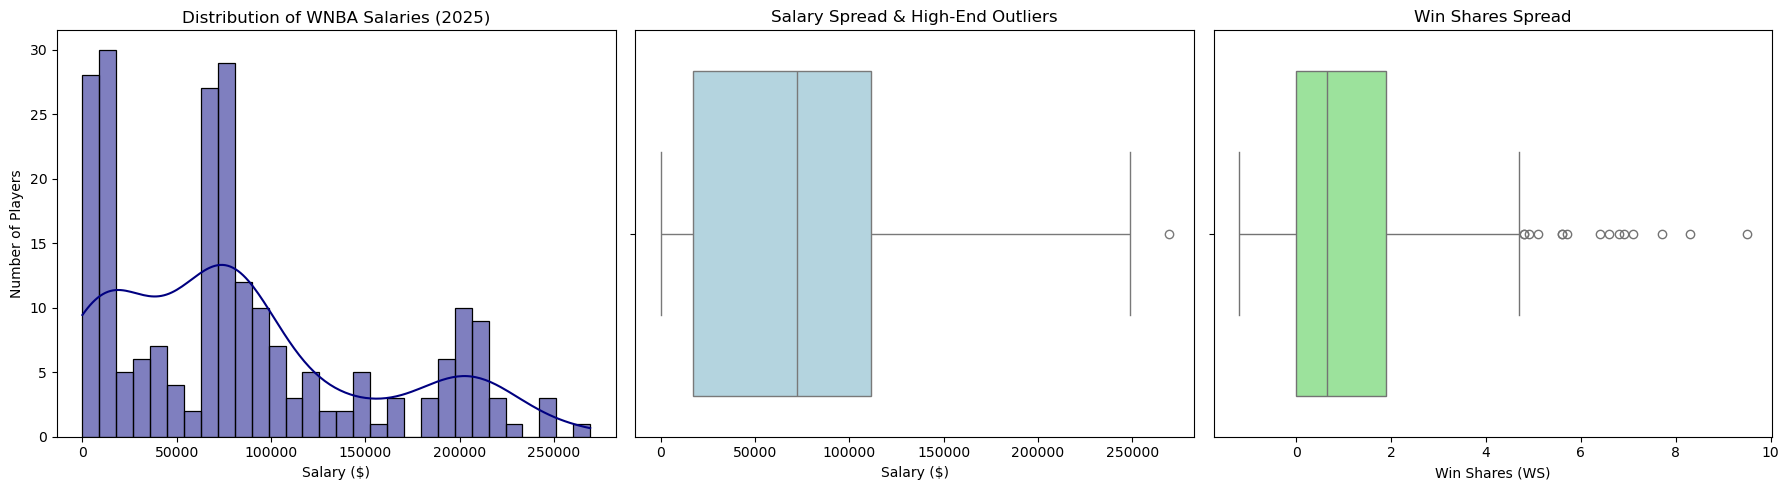

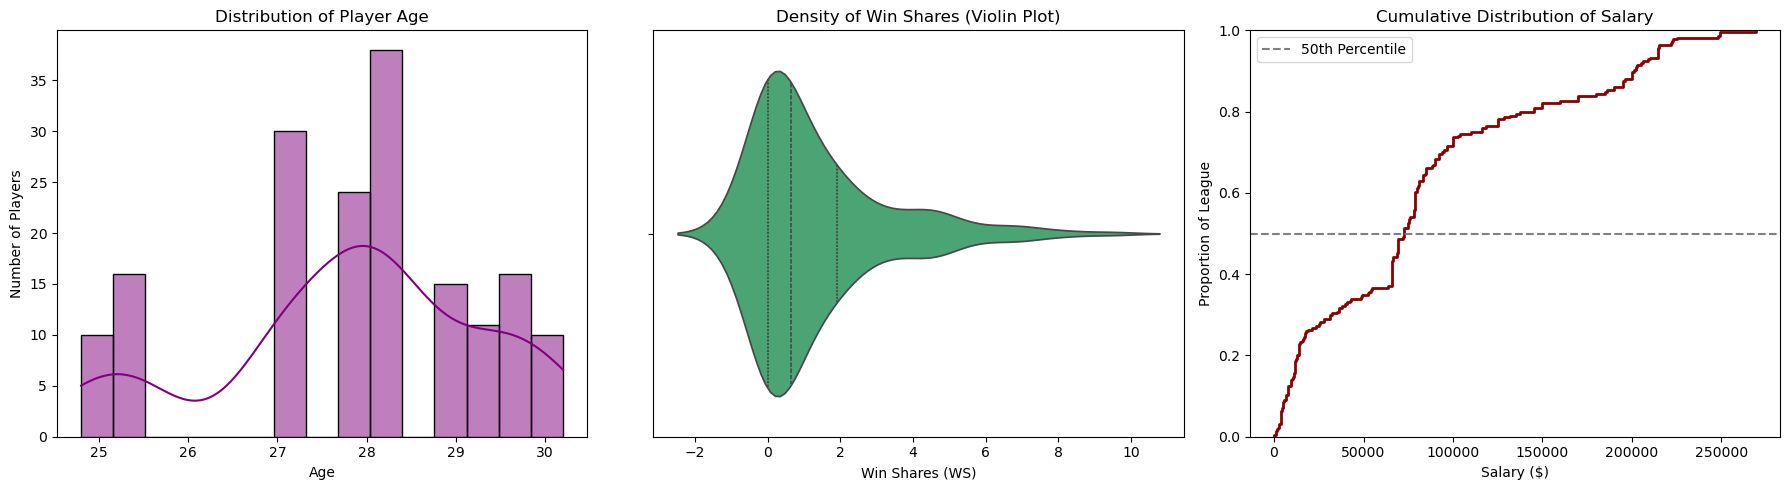

In [3]:
# Descriptions and descriptive stats

import matplotlib.pyplot as plt
import seaborn as sns

# Focus on salary and a few key advanced stats
columns_to_describe = ["salary", "ws", "age"] 
print("Baseline Descriptive Statistics")
display(final_df[columns_to_describe].describe().round(2))

# Setup the visualization grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE for Salary
sns.histplot(data=final_df, x="salary", kde=True, bins=30, ax=axes[0], color="navy")
axes[0].set_title("Distribution of WNBA Salaries (2025)")
axes[0].set_xlabel("Salary ($)")
axes[0].set_ylabel("Number of Players")

# Boxplot for Salary
sns.boxplot(data=final_df, x="salary", ax=axes[1], color="lightblue")
axes[1].set_title("Salary Spread & High-End Outliers")
axes[1].set_xlabel("Salary ($)")

# Boxplot for Win Shares
sns.boxplot(data=final_df, x="ws", ax=axes[2], color="lightgreen")
axes[2].set_title("Win Shares Spread")
axes[2].set_xlabel("Win Shares (WS)")

plt.tight_layout()
plt.show()

# Demographics, Density, and Percentiles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age Histogram + KDE
sns.histplot(data=final_df, x="age", kde=True, bins=15, ax=axes[0], color="purple")
axes[0].set_title("Distribution of Player Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of Players")

# Violin Plot for Win Shares
# A violin plot combines a boxplot with a KDE to show exactly where the data is "thickest"
sns.violinplot(data=final_df, x="ws", ax=axes[1], color="mediumseagreen", inner="quartile")
axes[1].set_title("Density of Win Shares (Violin Plot)")
axes[1].set_xlabel("Win Shares (WS)")

# Empirical Cumulative Distribution Function (ECDF) for Salary
sns.ecdfplot(data=final_df, x="salary", ax=axes[2], color="darkred", linewidth=2)
axes[2].set_title("Cumulative Distribution of Salary")
axes[2].set_xlabel("Salary ($)")
axes[2].set_ylabel("Proportion of League")
axes[2].axhline(0.5, color='gray', linestyle='--', label='50th Percentile')
axes[2].legend()

plt.tight_layout()
plt.show()

## 2. Missingness Analysis
**Objective:** Identify, quantify, and visualize missing data across our merged dataset. 

Data missingness can introduce bias or cause errors during model training. Understanding whether data is Missing Completely at Random (MCAR) or Missing at Random (MAR)—often tied to specific player types, low playing time, or data logging anomalies—helps us determine the correct imputation or filtering strategy.

Data Columns with Missing Values


,Missing Count,Percentage (%)
dummy_x,224,100.000000
dummy_y,224,100.000000
arena_name,211,94.196429
gb,69,30.803571
sos,54,24.107143
pace,54,24.107143
net_rtg,54,24.107143
def_rtg_y,54,24.107143
off_rtg_y,54,24.107143
srs,54,24.107143


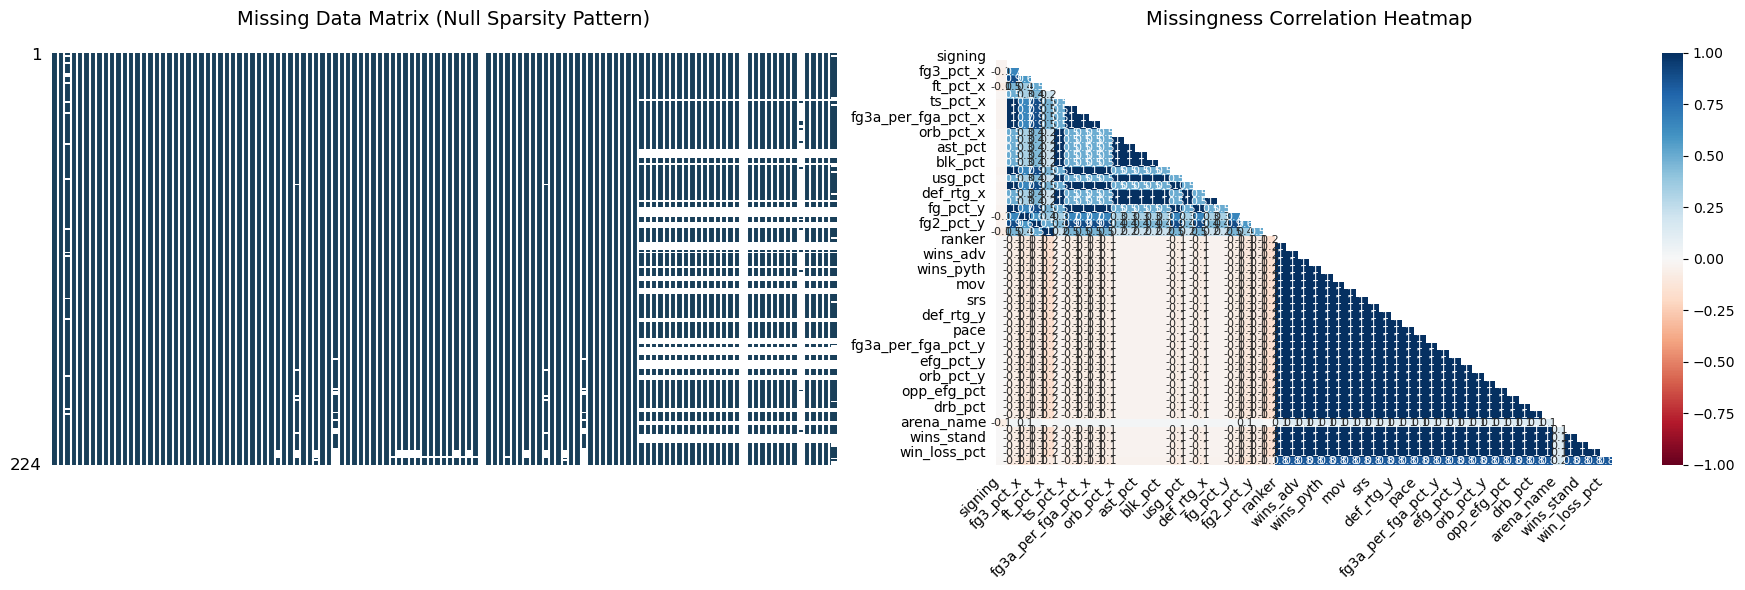

In [4]:
# Missingness analysis

# Quantify missingness using pandas.isna
missing_counts = final_df.isna().sum()
missing_percentages = (final_df.isna().sum() / len(final_df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Percentage (%)": missing_percentages
}).sort_values(by="Missing Count", ascending=False)

print("Data Columns with Missing Values")
display(missing_summary[missing_summary["Missing Count"] > 0])

# Setup a visualization grid for missingno plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Missingno Matrix
msno.matrix(final_df, ax=ax1, sparkline=False, color=(0.1, 0.25, 0.35), fontsize=10)
ax1.set_title("Missing Data Matrix (Null Sparsity Pattern)", fontsize=14, pad=20)

# Missingno Heatmap
if final_df.isna().sum().sum() > 0:
    msno.heatmap(final_df, ax=ax2, fontsize=10, cmap="RdBu")
    ax2.set_title("Missingness Correlation Heatmap", fontsize=14, pad=20)
else:
    ax2.text(0.5, 0.5, "No missing data found to correlate.", ha='center', va='center')
    ax2.set_title("Missingness Correlation Heatmap", fontsize=14)

plt.tight_layout()
plt.show()

## 3. Relationships Between Variables
**Objective:** Identify the linear and non-linear relationships between our predictive features (advanced stats, demographics) and our target variable (`salary`). 

By exploring scatterplots and correlation heatmaps, we can pinpoint which metrics most strongly dictate a player's financial value in the WNBA. Additionally, group summaries will help us understand the trajectory of production and compensation across a player's career.

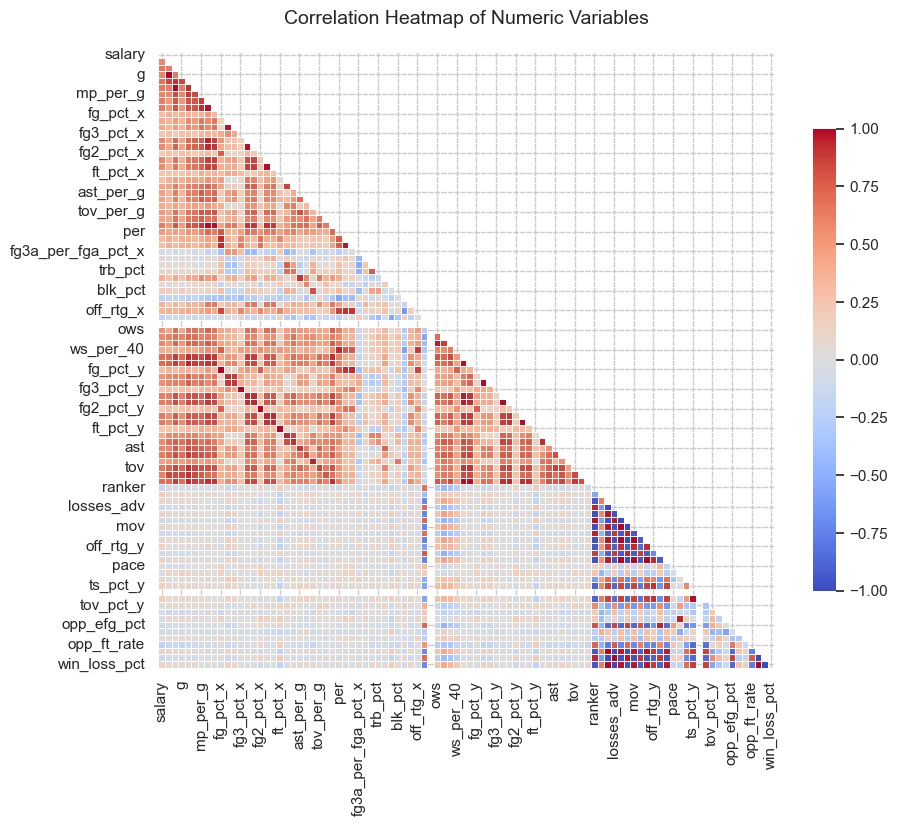

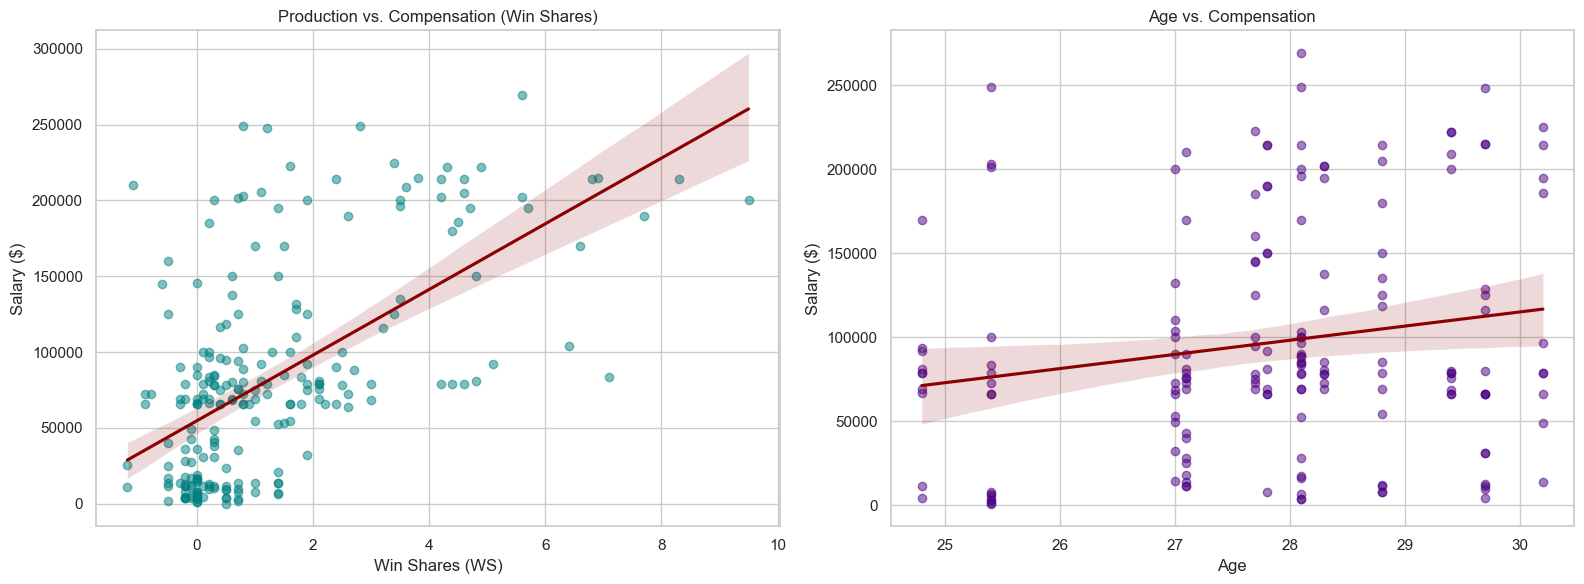

Career Trajectory: Average Salary & Production by Age


,Avg Salary ($),Player Count,Avg Win Shares
age,,,
24.8,74663.30,10,1.21
25.4,71742.81,16,0.71
27.0,84025.46,13,1.71
27.1,65444.12,17,0.13
27.7,122766.42,12,0.48
27.8,124244.58,12,2.99
28.1,97859.89,27,1.89
28.3,119668.82,11,1.52
28.8,96990.00,15,2.35


In [5]:
# Relationships

sns.set_theme(style="whitegrid")

# Correlation Heatmap
numeric_df = final_df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0, 
            annot=False, square=True, linewidths=.5, cbar_kws={"shrink": .75})
plt.title("Correlation Heatmap of Numeric Variables", pad=20, fontsize=14)
plt.show()


# Feature vs. Target Scatterplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Win Shares vs Salary
sns.regplot(data=final_df, x="ws", y="salary", ax=axes[0], 
            scatter_kws={"alpha": 0.5, "color": "teal"}, line_kws={"color": "darkred"})
axes[0].set_title("Production vs. Compensation (Win Shares)")
axes[0].set_xlabel("Win Shares (WS)")
axes[0].set_ylabel("Salary ($)")

# Age vs Salary
sns.regplot(data=final_df, x="age", y="salary", ax=axes[1], 
            scatter_kws={"alpha": 0.5, "color": "indigo"}, line_kws={"color": "darkred"})
axes[1].set_title("Age vs. Compensation")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Salary ($)")

plt.tight_layout()
plt.show()


# Group Summaries
age_group_summary = final_df.groupby("age").agg({
    "salary": ["mean", "count"],
    "ws": "mean"
}).round(2)

age_group_summary.columns = ["Avg Salary ($)", "Player Count", "Avg Win Shares"]
print("Career Trajectory: Average Salary & Production by Age")
display(age_group_summary.head(10))

## 4. Outlier Detection
**Objective:** Identify anomalous data points within our player universe that could disproportionately warp model parameters or distort predictive accuracy. 

We will look for outliers using three complementary approaches:
1. **Visual Inspection:** Re-examining boxplots to see the raw distance of point distributions.
2. **Statistical Thresholding (Z-scores):** Quantifying extreme deviance by flagging rows sitting more than 3 standard deviations from the feature means.
3. **Machine Learning Anomaly Detection (Isolation Forest):** Using an unsupervised ensemble model to flag multi-dimensional outliers based on combinations of features rather than isolated columns.

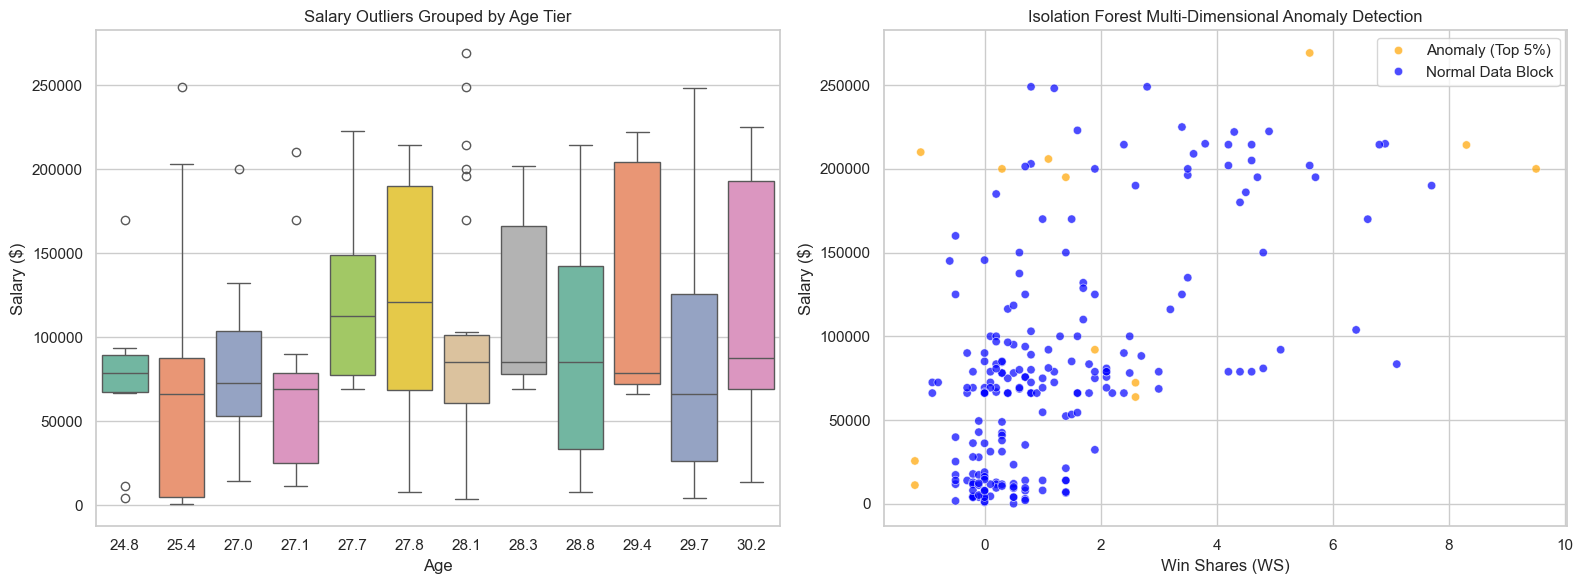

Z-Score Method: Found 4 Outlier Rows


,player,salary,ws,age
0,A'ja Wilson,200000,9.5,28.1
1,Napheesa Collier,214284,8.3,28.8
6,Allisha Gray,190000,7.7,27.8
19,Aliyah Boston,83371,7.1,28.1



Isolation Forest Method: Found 12 Outlier Rows


,player,salary,ws,age
0,A'ja Wilson,200000,9.5,28.1
1,Napheesa Collier,214284,8.3,28.8
2,Kelsey Mitchell,269244,5.6,28.1
23,Marina Mabrey,210000,-1.1,27.1
25,Brittney Sykes,195000,1.4,NaN


In [4]:
# Outliers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest

sns.set_theme(style="whitegrid")

# Statistical Outliers via Z-Score
numerical_cols = ["salary", "ws", "age"]
z_scores = np.abs(stats.zscore(final_df[numerical_cols].fillna(0)))

z_outlier_mask = (z_scores > 3).any(axis=1)
z_outliers_df = final_df[z_outlier_mask]


# Machine Learning Outliers via Isolation Forest
X_outliers = final_df[numerical_cols].fillna(0)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
final_df['iso_outlier_signal'] = iso_forest.fit_predict(X_outliers)

iso_outliers_df = final_df[final_df['iso_outlier_signal'] == -1]


# Visualizing the Anomalies
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot showing statistical range limits
sns.boxplot(data=final_df, y="salary", x="age", hue="age", ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Salary Outliers Grouped by Age Tier")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Salary ($)")

# Scatterplot showing how the Isolation Forest drew its anomaly boundary
sns.scatterplot(data=final_df, x="ws", y="salary", hue="iso_outlier_signal", 
                palette={1: "blue", -1: "orange"}, alpha=0.7, ax=axes[1])
axes[1].set_title("Isolation Forest Multi-Dimensional Anomaly Detection")
axes[1].set_xlabel("Win Shares (WS)")
axes[1].set_ylabel("Salary ($)")
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ["Anomaly (Top 5%)", "Normal Data Block"])

plt.tight_layout()
plt.show()

# Print the Flagged Outliers
print(f"Z-Score Method: Found {len(z_outliers_df)} Outlier Rows")
display(z_outliers_df[["player", "salary", "ws", "age"]].head(5))

print(f"\nIsolation Forest Method: Found {len(iso_outliers_df)} Outlier Rows")
display(iso_outliers_df[["player", "salary", "ws", "age"]].head(5))

Time-series analysis does not make sense for this stage of the project because, so far, we are only analyzing the year 2025.